In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# بارگذاری داده
housing = fetch_california_housing(as_frame=True).frame

# گزارش اطلاعات
print(f"Shape: {housing.shape}")
print(f"Missing values: {housing.isnull().sum().sum()}")
print(f"Duplicated rows: {housing.duplicated().sum()}")

Shape: (20640, 9)
Missing values: 0
Duplicated rows: 0


In [3]:
rng = np.random.default_rng(0)
housing_messy = housing.copy()
n_rows = len(housing_messy)
# انتخاب تصادفی ۵٪ از اندیس‌ها
mask = rng.choice(n_rows, size=int(0.05 * n_rows), replace=False)
housing_messy.loc[mask, "Population"] = np.nan

missing_count = housing_messy["Population"].isna().sum()
print(f"Missing values in Population after introducing NaN: {missing_count}")

Missing values in Population after introducing NaN: 1032


In [4]:
# حذف سطرهای گم‌شده
mean_drop = housing_messy["Population"].dropna().mean()

# پر کردن با میانه
median_val = housing_messy["Population"].median()
housing_filled = housing_messy["Population"].fillna(median_val)
mean_fill = housing_filled.mean()

print(f"Mean after dropping: {mean_drop:.4f}")
print(f"Mean after filling with median: {mean_fill:.4f}")
print(f"Difference: {abs(mean_drop - mean_fill):.4f}")
# توضیح: چون میانه به شدت تحت تأثیر داده‌های پرت نیست، و تنها ۵٪ داده گم شده‌اند،
# میانگین پر شده با میانه ممکن است به میانگین واقعی نزدیک‌تر باشد یا تفاوت ناچیزی داشته باشد.

Mean after dropping: 1423.9821
Mean after filling with median: 1411.0330
Difference: 12.9491


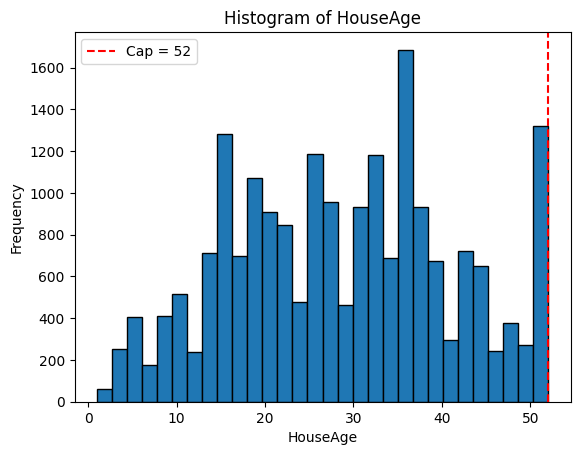

Fraction of rows exactly at cap 52: 0.0617


In [5]:
import matplotlib.pyplot as plt

cap = 52
house_age = housing["HouseAge"]
fraction_at_cap = (house_age == cap).mean()

plt.hist(house_age, bins=30, edgecolor='black')
plt.axvline(cap, color='red', linestyle='--', label=f'Cap = {cap}')
plt.xlabel("HouseAge")
plt.ylabel("Frequency")
plt.title("Histogram of HouseAge")
plt.legend()
plt.show()

print(f"Fraction of rows exactly at cap {cap}: {fraction_at_cap:.4f}")

In [6]:
# داده اصلی و پاک (بدون مقادیر گم‌شده)
ave_rooms = housing["AveRooms"]

Q1 = ave_rooms.quantile(0.25)
Q3 = ave_rooms.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_count = (ave_rooms > upper_bound).sum()
print(f"Upper bound for AveRooms: {upper_bound:.4f}")
print(f"Number of rows exceeding upper bound: {outliers_count}")

Upper bound for AveRooms: 8.4699
Number of rows exceeding upper bound: 466


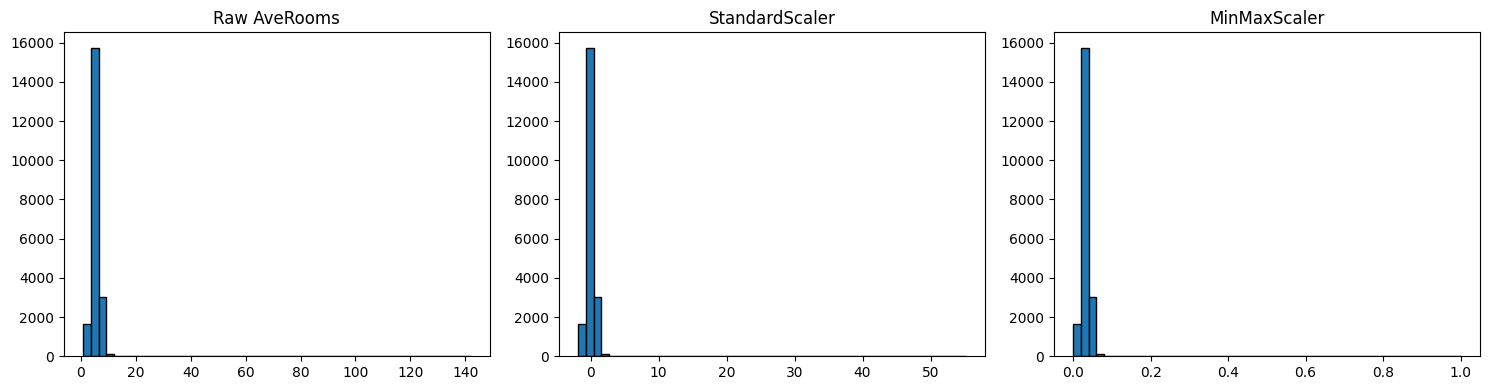

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# داده را به صورت آرایه دو‌بعدی برای اسکالرها آماده می‌کنیم
X = housing[["AveRooms"]].values

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X, bins=50, edgecolor='black')
axes[0].set_title("Raw AveRooms")
axes[1].hist(X_std, bins=50, edgecolor='black')
axes[1].set_title("StandardScaler")
axes[2].hist(X_minmax, bins=50, edgecolor='black')
axes[2].set_title("MinMaxScaler")
plt.tight_layout()
plt.show()

# توضیح: در هیستوگرام MinMaxScaler، به دلیل وجود مقادیر پرت (بسیار بزرگ)،
# اکثر داده‌ها در بازه‌ای بسیار باریک (نزدیک صفر) فشرده می‌شوند، در حالی که
# StandardScaler داده‌ها را بر اساس انحراف معیار مقیاس می‌کند و پرت‌ها همچنان
# در انتهای توزیع قابل‌تشخیص هستند (دم بلند). بنابراین MinMaxScaler به وضوح
# توسط پرت‌ها مخدوش می‌شود.

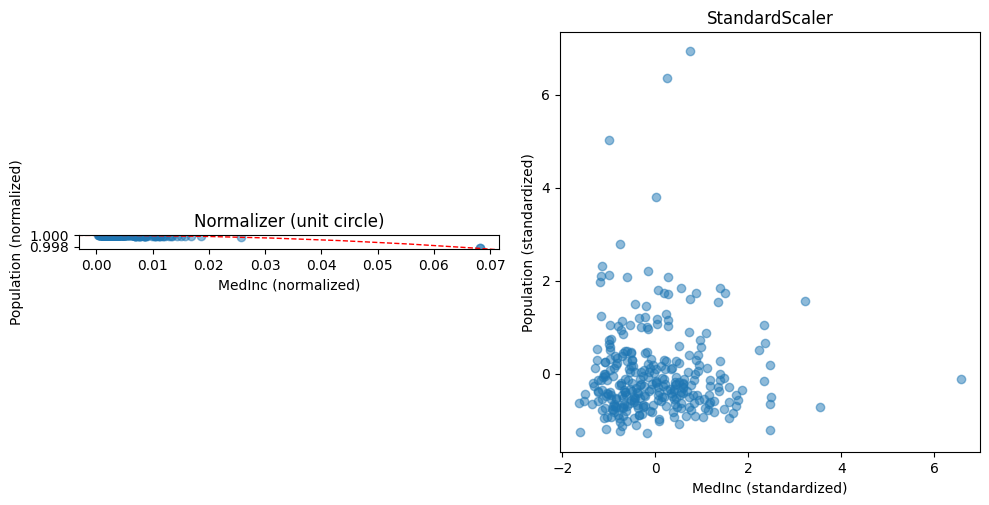

In [8]:
from sklearn.preprocessing import Normalizer

# نمونه‌گیری
sample = housing[["MedInc", "Population"]].sample(300, random_state=0)

# نرمال‌سازی با Normalizer (هر سطر به طول واحد تبدیل می‌شود)
norm = Normalizer()
sample_norm = norm.fit_transform(sample)

# استانداردسازی با StandardScaler
scaler = StandardScaler()
sample_std = scaler.fit_transform(sample)

# رسم
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# رسم داده‌های نرمال‌شده با دایره واحد
ax1.scatter(sample_norm[:, 0], sample_norm[:, 1], alpha=0.5)
# افزودن دایره واحد
circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
ax1.add_artist(circle)
ax1.set_aspect('equal')
ax1.set_title("Normalizer (unit circle)")
ax1.set_xlabel("MedInc (normalized)")
ax1.set_ylabel("Population (normalized)")

# رسم داده‌های استانداردشده
ax2.scatter(sample_std[:, 0], sample_std[:, 1], alpha=0.5)
ax2.set_aspect('equal')
ax2.set_title("StandardScaler")
ax2.set_xlabel("MedInc (standardized)")
ax2.set_ylabel("Population (standardized)")

plt.tight_layout()
plt.show()

# توضیح: Normalizer هر نمونه را به‌طور جداگانه به طول اقلیدسی واحد می‌رساند،
# بنابراین تمام نقاط روی دایره واحد قرار می‌گیرند. اما StandardScaler فقط هر
# ویژگی را به‌طور مستقل میانگین‌گیری و مقیاس‌سازی می‌کند و هیچ شرطی برای
# قرار گرفتن نقاط روی دایره ندارد؛ بنابراین شکل توزیع به صورت بیضوی یا
# کشیده باقی می‌ماند و دایره‌ای نمی‌شود.